# Generation of graph data from existing graphs

In [1]:
import networkx
import numpy as np

# import torch
# import torch_geometric

# import scipy

import matplotlib.pyplot as plt
import pyvista as pv
import os

import pickle

In [2]:
# Choose backend for matplotlib
# -----------------------------
from IPython import get_ipython
# get_ipython().run_line_magic('matplotlib', 'widget')
get_ipython().run_line_magic('matplotlib', 'inline')

# Or simply:
# %matplotlib widget
# %matplotlib inline

In [3]:
# Choose backend for pyvista with jupyter
# ---------------------------------------
# pv.set_jupyter_backend('trame')  # 3D-interactive plots
pv.set_jupyter_backend('static') # static plots

# Notes:
# -> ignored if run in a standard python shell
# -> use keyword argument "notebook=False" in Plotter() to open figure in a pop-up window

## Load local functions 

In [4]:
print('Load local functions...')

# import sys
# sys.path.insert(1, '../utils/')

# from graph_utils import *
# from graph_plot import *
# # from magic_utils import *

with open('../utils/graph_utils.py') as f: exec(f.read())
with open('../utils/graph_plot.py') as f: exec(f.read())
# with open('../utils/magic_utils.py') as f: exec(f.read())

Load local functions...


<string>:830: SyntaxWarning: invalid escape sequence '\m'
<string>:866: SyntaxWarning: invalid escape sequence '\m'


## Load parameters

Some parameters (dimension / attribute considered and indexes / parameters for plotting graphs)


In [5]:
print('Load parameters...')

# from params import *

with open('params.py') as f: exec(f.read())

Load parameters...


## Output settings

In [6]:
print('Define output settings...')

# Settings 
# ========

# Output directories
# ------------------
out_dir = 'data_gen' # PARAMS
fig_dir = 'fig'      # PARAMS

plt_show = True      # PARAMS (show graphics 2D ?)
off_screen = False   # PARAMS (show graphics 3D ?)

save_fig_png = True  # PARAMS
fig_prefix = '00'    # PARAMS

fig_counter = 0

if not os.path.isdir(out_dir):
    os.mkdir(out_dir)

if not os.path.isdir(fig_dir):
    os.mkdir(fig_dir)

# Files for saving data set / test set (pickle, text file) (see further)
# ----------------------------------------------------------------------
filename_data_set_pk = os.path.join(out_dir, f'graph_collection_data_set.pickle')
filename_test_set_pk = os.path.join(out_dir, f'graph_collection_test_set.pickle')

filename_data_set_basename_txt = 'graph_collection_data_set'
filename_test_set_basename_txt = 'graph_collection_test_set'


Define output settings...


## Do not edit ABOVE

## Input : main graph

In [7]:
print('Read main graph...')

# Read main graph
# ---------------
# Read from pickle file
input_file = f'../data/Tsanfleuron/tsan_largest_cc.pickle'  # PARAMS

with open(input_file, 'rb') as f:
    G_main = pickle.load(f)

G_main = networkx.convert_node_labels_to_integers(G_main)

print(f'Nb of connected components: {networkx.number_connected_components(G_main)}')


Read main graph...
Nb of connected components: 1


In [8]:
self_loops = list(networkx.selfloop_edges(G_main))
G_main.remove_edges_from(self_loops)

In [9]:
print('Set main graph (networkx)...')

G_main = remove_all_node_attributes_but(G_main, ['pos', attr])

Set main graph (networkx)...


## Plot main graph

Plot main graph (2D)...


<string>:458: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


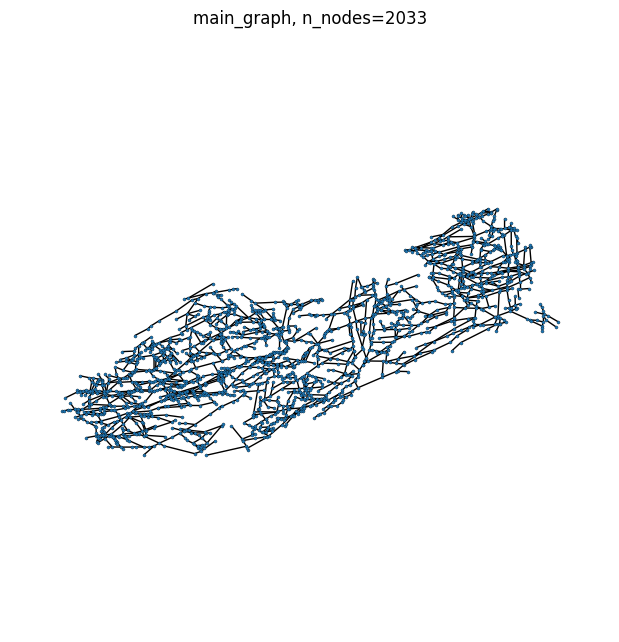

In [10]:
print('Plot main graph (2D)...')

# Plot main graph 2d
# ==================
kwds = kwds_single.copy()

kwds['node_size'] = 5 # adapt node size
# kwds['width'] = .5     # adapt edge width

figsize = figsize_single
# -----

out_name = 'main_graph'
plot_graph_single_2d_from_G_networkx(
        G_main, 
        out_name=out_name, 
        attr=attr,
        attr_label_list=attr_label_list, 
        attr_cmap_list=attr_cmap_list,
        title=None, title_fontsize=12,
        figsize=figsize, save_fig_png=save_fig_png, 
        filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
        with_labels=False, show_color_bar=True,
        show=plt_show,
        **kwds)


Plot main graph (3D)...


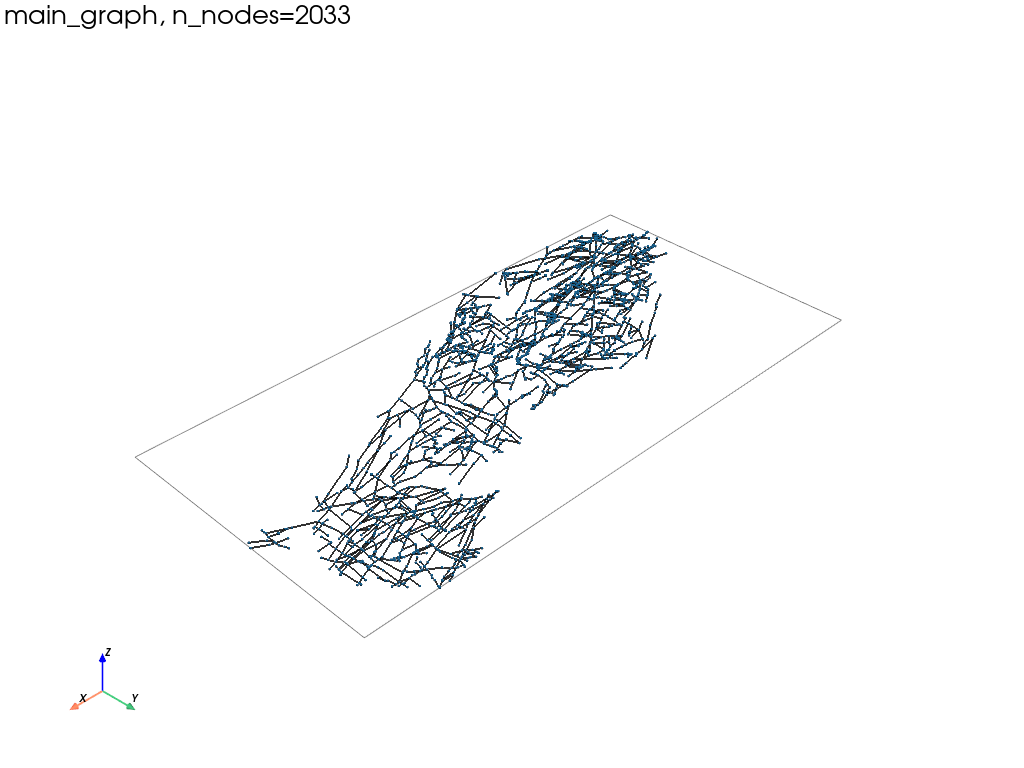

In [11]:
print('Plot main graph (3D)...')

# Plot main graph 3d
# ==================
kwargs_edges = kwargs_edges_single.copy()
kwargs_pts = kwargs_pts_single.copy()
kwargs_pts_labels = kwargs_pts_labels_single.copy()
kwargs_scalar_bar = kwargs_scalar_bar_single.copy()

kwargs_pts['point_size'] = 3 # adapt node size
# kwargs_edges['line_width'] = # adapt edge width

window_size = window_size_single
# -----

# notebook = False # pop-up window
# cpos = None

# notebook = True  # inline
# cpos = \
# [(517786.43175783526, 171033.62200323722, 3228.2267989145184),
#  (516160.734375, 171889.74, 813.3000061035157),
#  (-0.798043530972574, 0.13872899139143935, 0.5864134971334989)]

notebook = True  # inline
cpos = None

out_name = 'main_graph'
plot_graph_single_3d_from_G_networkx(
        G_main, 
        out_name=out_name, 
        attr=attr,
        attr_label_list=attr_label_list, 
        attr_cmap_list=attr_cmap_list,
        title=None, title_fontsize=12,
        notebook=notebook, window_size=window_size, save_fig_png=save_fig_png, off_screen=off_screen,
        filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
        with_labels=False, show_color_bar=True,
        kwargs_edges=kwargs_edges, kwargs_pts=kwargs_pts, kwargs_scalar_bar=kwargs_scalar_bar, kwargs_pts_labels=kwargs_pts_labels,
        cpos=cpos, print_cpos=False)


In [12]:
if save_fig_png:
    fig_counter = fig_counter+1


### Extract x, y coordinates of nodes position - 2D case

In [13]:
print('Extract x, y coordinates (set main graph in 2D)...')

G_main = extract_graph_node_features_indices(G_main, 'pos', (0, 1)) # inplace operation

Extract x, y coordinates (set main graph in 2D)...


## Generate data - collection of subgraphs

In [14]:
print('Define settings for collection of subgraphs...')

# Settings
# --------
# # min and max number of nodes to extract for each subgraph
# min_n_nodes, max_n_nodes = 120, 150

# mean and std for number of nodes (gaussian) to extract for each subgraph
mean_n_nodes, std_n_nodes = 300.0, 30.0
min_n_nodes = 30 # Truncated distribution

n_subgraph_data_set = 500
n_subgraph_test_set = 50


Define settings for collection of subgraphs...


## Do not edit BELOW

### Build collection - training set

In [15]:
print('Generate data set (collection of subgraphs)...')

# Generate list of subgraphs - data set
# -------------------------------------
seed = 923

np.random.seed(seed)
# n_nodes = np.random.randint(min_n_nodes, max_n_nodes+1, n_subgraph_data_set)

n_nodes = np.round(np.random.normal(loc=mean_n_nodes, scale=std_n_nodes, size=n_subgraph_data_set)).astype('int')
while np.any(n_nodes < min_n_nodes):
    m = np.sum(n_nodes < min_n_nodes) # > 0
    print(f'Reject number of nodes ({m}) too small (<{min_n_nodes}) and redraw...')
    n_nodes[n_nodes < min_n_nodes] = np.round(np.random.normal(loc=mean_n_nodes, scale=std_n_nodes, size=m)).astype('int')

G_list_data_set = [extract_subgraph_from_bfs(G_main, n) for n in n_nodes]

# # Express node features (position) in PCA axes (no normalization)
# for G in G_list_data_set:
#     G = pca_graph_node_features(G, 'pos', normalize=False, return_initial_mean_and_pca=False) # inplace operation

# Centralize graphs (mean at zero)
for G in G_list_data_set:
    G = centralize_graph_node_features(G, 'pos', inplace=True, return_initial_mean=False)


Generate data set (collection of subgraphs)...


Plot data set (2D)...


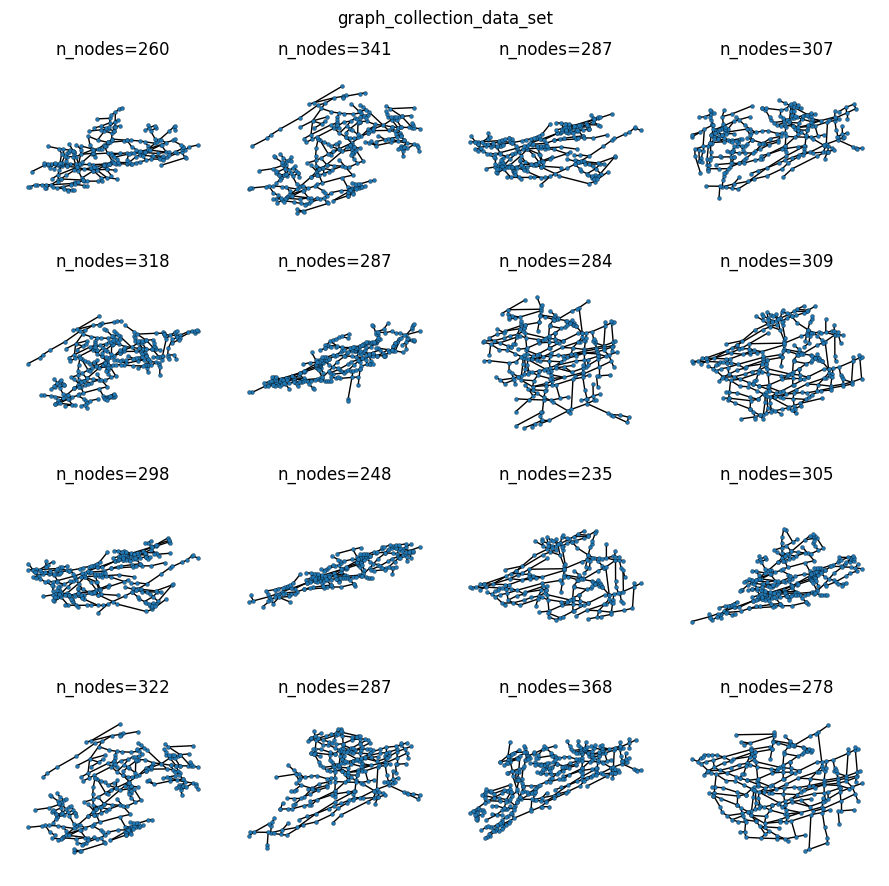

In [16]:
print('Plot data set (2D)...')

G_list = G_list_data_set[:16]
out_name = 'graph_collection_data_set'

# 2D view
# =======
kwds = kwds_multi.copy()

figsize = figsize_multi
# -----

same_color_bar = False

plot_graph_multi_2d_from_G_networkx_list(
        G_list, 
        out_name=out_name, 
        nr=None,
        attr=attr,
        attr_label_list=attr_label_list, 
        attr_cmap_list=attr_cmap_list,
        title_list=None, title_fontsize=12,
        figsize=figsize, save_fig_png=save_fig_png, 
        filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
        with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
        show=plt_show,
        **kwds)

In [17]:
# %%skip_if dim == 2
if dim == 3:
    print('Plot data set (3D)...')

    G_list = G_list_data_set[:9]
    out_name = 'graph_collection_data_set'

    # Plot first graphs - 3d
    # ======================
    kwargs_edges = kwargs_edges_multi.copy()
    kwargs_pts = kwargs_pts_multi.copy()
    kwargs_pts_labels = kwargs_pts_labels_multi.copy()
    kwargs_scalar_bar = kwargs_scalar_bar_multi.copy()

    window_size = window_size_multi
    # -----

    # notebook = False # pop-up window
    # cpos = None

    # notebook = True  # inline
    # cpos = \
    # [(410.42840368821584, -176.08643814594834, 230.59557647292922),
    #  (4.909560043666214, -1.6530085484822958, -26.67373480252808),
    #  (-0.4692582625497324, 0.18316710716520687, 0.8638555978180245)]

    notebook = True  # inline
    cpos = None

    same_color_bar = False

    plot_graph_multi_3d_from_G_networkx_list(
            G_list, 
            out_name=out_name, 
            nr=None,
            attr=attr,
            attr_label_list=attr_label_list, 
            attr_cmap_list=attr_cmap_list,
            title_list=None, title_fontsize=12,
            notebook=notebook, window_size=window_size, save_fig_png=save_fig_png, off_screen=off_screen,
            filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
            with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
            kwargs_edges=kwargs_edges, kwargs_pts=kwargs_pts, kwargs_scalar_bar=kwargs_scalar_bar, kwargs_pts_labels=kwargs_pts_labels,
            cpos=cpos, print_cpos=False)


In [18]:
if save_fig_png:
    fig_counter = fig_counter+1


### Build collection - test set

In [19]:
print('Generate test set (collection of subgraphs)...')

# Generate list of subgraphs
# --------------------------
seed = 888

np.random.seed(seed)
# n_nodes = np.random.randint(min_n_nodes, max_n_nodes+1, n_subgraph_test_set)

n_nodes = np.round(np.random.normal(loc=mean_n_nodes, scale=std_n_nodes, size=n_subgraph_test_set)).astype('int')
while np.any(n_nodes < min_n_nodes):
    m = np.sum(n_nodes < min_n_nodes) # > 0
    print(f'Reject number of nodes ({m}) too small (<{min_n_nodes}) and redraw...')
    n_nodes[n_nodes < min_n_nodes] = np.round(np.random.normal(loc=mean_n_nodes, scale=std_n_nodes, size=m)).astype('int')

G_list_test_set = [extract_subgraph_from_bfs(G_main, n) for n in n_nodes]

# # Express node features (position) in PCA axes (no normalization)
# for G in G_list:
#     G = pca_graph_node_features(G, 'pos', normalize=False, return_initial_mean_and_pca=False) # inplace operation

# Centralize graphs (mean at zero)
for G in G_list_test_set:
    G = centralize_graph_node_features(G, 'pos', inplace=True, return_initial_mean=False)


Generate test set (collection of subgraphs)...


Plot test set (2D)...


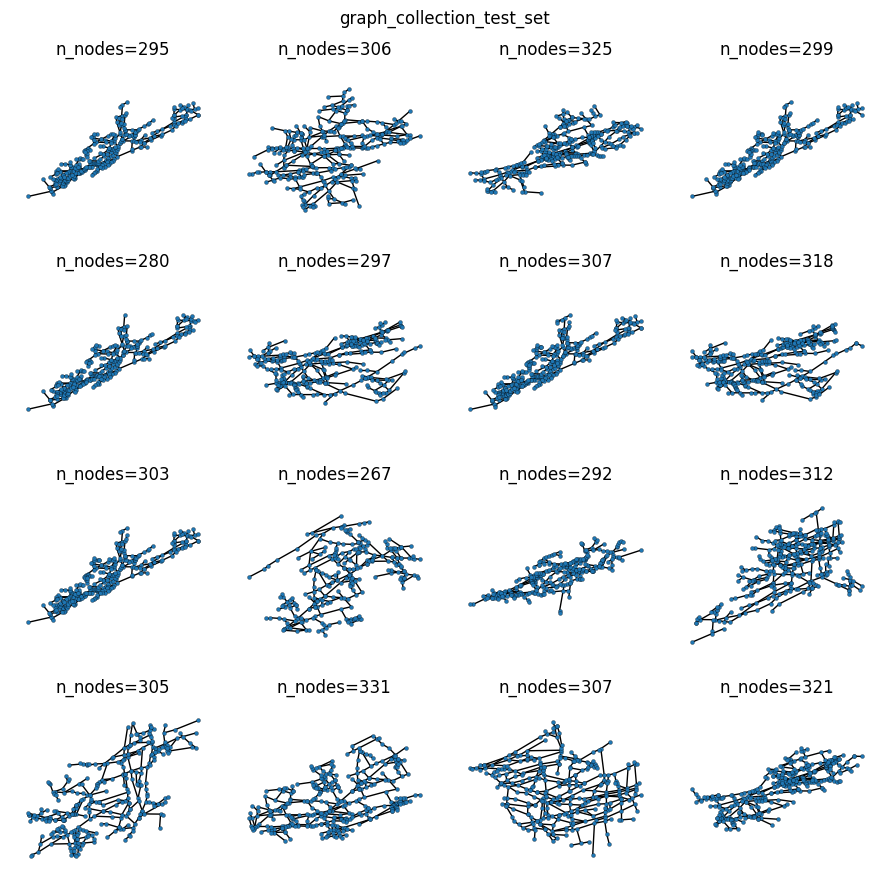

In [20]:
print('Plot test set (2D)...')

G_list = G_list_test_set[:16]
out_name = 'graph_collection_test_set'

# 2D view
# =======
kwds = kwds_multi.copy()

figsize = figsize_multi
# -----

same_color_bar = False

plot_graph_multi_2d_from_G_networkx_list(
        G_list, 
        out_name=out_name, 
        nr=None,
        attr=attr,
        attr_label_list=attr_label_list, 
        attr_cmap_list=attr_cmap_list,
        title_list=None, title_fontsize=12,
        figsize=figsize, save_fig_png=save_fig_png, 
        filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
        with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
        show=plt_show,
        **kwds)

In [21]:
# %%skip_if dim == 2
if dim == 3:
    print('Plot test set (3D)...')

    G_list = G_list_test_set[:9]
    out_name = 'graph_collection_test_set'

    # Plot first graphs - 3d
    # ======================
    kwargs_edges = kwargs_edges_multi.copy()
    kwargs_pts = kwargs_pts_multi.copy()
    kwargs_pts_labels = kwargs_pts_labels_multi.copy()
    kwargs_scalar_bar = kwargs_scalar_bar_multi.copy()

    window_size = window_size_multi
    # -----

    # notebook = False # pop-up window
    # cpos = None

    # notebook = True  # inline
    # cpos = \
    # [(410.42840368821584, -176.08643814594834, 230.59557647292922),
    #  (4.909560043666214, -1.6530085484822958, -26.67373480252808),
    #  (-0.4692582625497324, 0.18316710716520687, 0.8638555978180245)]

    notebook = True  # inline
    cpos = None

    same_color_bar = False

    plot_graph_multi_3d_from_G_networkx_list(
            G_list, 
            out_name=out_name, 
            nr=None,
            attr=attr,
            attr_label_list=attr_label_list, 
            attr_cmap_list=attr_cmap_list,
            title_list=None, title_fontsize=12,
            notebook=notebook, window_size=window_size, save_fig_png=save_fig_png, off_screen=off_screen,
            filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
            with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
            kwargs_edges=kwargs_edges, kwargs_pts=kwargs_pts, kwargs_scalar_bar=kwargs_scalar_bar, kwargs_pts_labels=kwargs_pts_labels,
            cpos=cpos, print_cpos=False)


In [22]:
if save_fig_png:
    fig_counter = fig_counter+1


## Save / Export

### Save the data set / test set (collections of (sub)graphs)

In [23]:
print('Save / export data set and test set...')

# Save in pickle file
# -------------------
# data set
with open(filename_data_set_pk, 'wb') as f: pickle.dump(G_list_data_set, file=f)
# test set
with open(filename_test_set_pk, 'wb') as f: pickle.dump(G_list_test_set, file=f)

# Save in text files
# ------------------
# data set
save_networkx_graph_list(G_list_data_set, out_dir, filename_data_set_basename_txt, node_attrs=['pos', attr])
# test set
save_networkx_graph_list(G_list_test_set, out_dir, filename_test_set_basename_txt, node_attrs=['pos', attr])

Save / export data set and test set...
